# Datathon Passos Mágicos — Modelo Preditivo de Risco de Defasagem
### Fase 5 | PosTech — Data Analytics

**Objetivo (pergunta 9 do desafio):** construir um modelo preditivo que estime a
**probabilidade de um aluno entrar em risco de defasagem** no ano seguinte, a partir
dos indicadores do ano corrente.

**Definição do alvo:** `Risco_Defasagem_Futuro = 1` se, no ano seguinte, o aluno
apresentar `Defasagem <= -1` (moderadamente ou severamente defasado); `0` caso contrário.

Etapas deste notebook:
1. Feature engineering
2. Separação treino/teste (split temporal)
3. Modelagem preditiva (comparação de algoritmos)
4. Avaliação dos resultados
5. Exportação do modelo treinado (para uso no app Streamlit)


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve, f1_score
)
import joblib

sns.set_style("whitegrid")
COR_AZUL, COR_LARANJA = "#1B4F72", "#E8871E"
np.random.seed(42)

df = pd.read_csv("../data/processed/pede_painel_2022_2024.csv")
print(df.shape)


(3030, 30)


## 1. Feature Engineering

Construímos a variável-alvo olhando o valor de `Defasagem` do **ano seguinte** para o
mesmo aluno (RA), usando o painel longitudinal. As features utilizadas são os indicadores
do ano corrente (ano em que a previsão seria feita, na prática).


In [2]:

df = df.sort_values(["RA", "Ano"]).reset_index(drop=True)

# Variável-alvo: defasagem no ano seguinte
df["Defasagem_next"] = df.groupby("RA")["Defasagem"].shift(-1)
df["Ano_next"] = df.groupby("RA")["Ano"].shift(-1)

# Mantemos apenas observações com ano seguinte consecutivo disponível (ex.: 2022->2023, 2023->2024)
base = df[df["Ano_next"] - df["Ano"] == 1].copy()
base["Risco_Defasagem_Futuro"] = (base["Defasagem_next"] <= -1).astype(int)

print("Distribuição do alvo:")
print(base["Risco_Defasagem_Futuro"].value_counts(normalize=True).round(3))
print("\nTotal de observações utilizáveis:", base.shape[0])


Distribuição do alvo:
Risco_Defasagem_Futuro
0    0.506
1    0.494
Name: proportion, dtype: float64

Total de observações utilizáveis: 1365


**Nota de feature engineering:** o indicador **IPP** só passou a ser coletado a partir de
2023 (ausente na base de 2022). Como usaremos a transição 2022→2023 como treino, o IPP foi
**excluído do conjunto principal de features** para não descartar toda a safra de 2022 por
valores nulos — mantendo o modelo comparável e treinável em ambas as transições disponíveis.


In [3]:

FEATURES_NUM = ["IAN", "IDA", "IEG", "IAA", "IPS", "IPV", "INDE",
                "Fase_num", "Idade", "Anos_na_PM", "Nota_Mat", "Nota_Por"]
FEATURES_CAT = ["Genero", "Instituicao_ensino"]

modelo_df = base.dropna(subset=FEATURES_NUM + ["Risco_Defasagem_Futuro"]).copy()
print("Linhas após remover nulos nas features numéricas:", modelo_df.shape[0])

X = modelo_df[FEATURES_NUM + FEATURES_CAT]
y = modelo_df["Risco_Defasagem_Futuro"]
ano_ref = modelo_df["Ano"]  # usado para o split temporal
print(modelo_df["Ano"].value_counts())


Linhas após remover nulos nas features numéricas: 1290
Ano
2023    690
2022    600
Name: count, dtype: int64


## 2. Separação treino/teste

Optamos por um **split temporal**: treinamos com a transição **2022→2023** e testamos com a
transição **2023→2024**. Essa abordagem simula melhor o uso real do modelo (prever o futuro
com base no passado) do que um split aleatório, e evita vazamento de informação entre anos.


In [4]:

train_mask = ano_ref == 2022
test_mask = ano_ref == 2023

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Treino (transição 2022->2023):", X_train.shape[0], "| taxa positiva:", round(y_train.mean(), 3))
print("Teste  (transição 2023->2024):", X_test.shape[0], "| taxa positiva:", round(y_test.mean(), 3))


Treino (transição 2022->2023): 600 | taxa positiva: 0.61
Teste  (transição 2023->2024): 690 | taxa positiva: 0.442


## 3. Modelagem preditiva

Testamos três algoritmos: **Regressão Logística** (baseline interpretável), **Random Forest**
e **Gradient Boosting**. Usamos um `Pipeline` com pré-processamento (padronização de
numéricas + one-hot de categóricas) e validação cruzada (5-fold, estratificada) no conjunto
de treino para escolher o melhor modelo antes de avaliar no teste.


In [5]:

preprocess = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])

modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = {}

for nome, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocess), ("clf", modelo)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    resultados_cv[nome] = scores
    print(f"{nome:22s} | AUC-ROC (CV 5-fold): {scores.mean():.3f} +/- {scores.std():.3f}")


Regressão Logística    | AUC-ROC (CV 5-fold): 0.843 +/- 0.041


Random Forest          | AUC-ROC (CV 5-fold): 0.822 +/- 0.065


Gradient Boosting      | AUC-ROC (CV 5-fold): 0.854 +/- 0.051


/tmp/ipykernel_701/2266533552.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(resultados_cv.values(), labels=resultados_cv.keys())


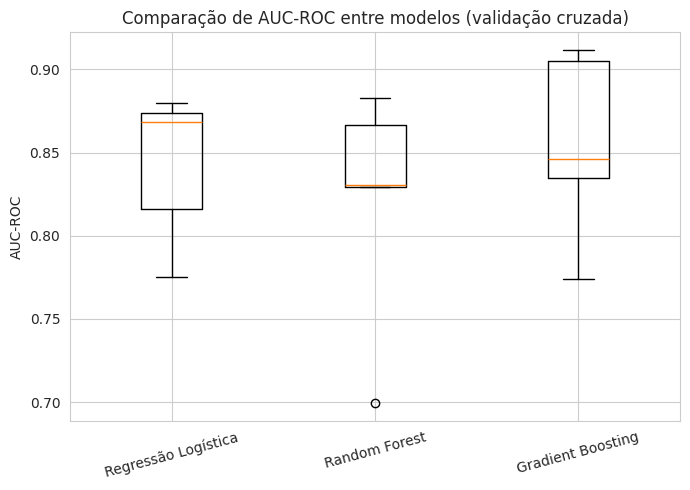

In [6]:

fig, ax = plt.subplots(figsize=(7,5))
ax.boxplot(resultados_cv.values(), labels=resultados_cv.keys())
ax.set_title("Comparação de AUC-ROC entre modelos (validação cruzada)")
ax.set_ylabel("AUC-ROC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../presentation/fig_modelo_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Avaliação dos resultados no conjunto de teste

Selecionamos o modelo com melhor desempenho médio em validação cruzada e avaliamos no
conjunto de teste (transição 2023→2024, nunca visto durante o treino/tuning).


In [7]:

melhor_nome = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
print("Modelo selecionado:", melhor_nome)

pipe_final = Pipeline([("prep", preprocess), ("clf", modelos[melhor_nome])])
pipe_final.fit(X_train, y_train)

y_pred = pipe_final.predict(X_test)
y_proba = pipe_final.predict_proba(X_test)[:, 1]

print("\n=== Relatório de classificação (conjunto de teste) ===")
print(classification_report(y_test, y_pred, target_names=["Sem risco", "Em risco"]))
print("AUC-ROC (teste):", round(roc_auc_score(y_test, y_proba), 3))


Modelo selecionado: Gradient Boosting



=== Relatório de classificação (conjunto de teste) ===
              precision    recall  f1-score   support

   Sem risco       0.76      0.82      0.79       385
    Em risco       0.75      0.67      0.70       305

    accuracy                           0.75       690
   macro avg       0.75      0.74      0.75       690
weighted avg       0.75      0.75      0.75       690

AUC-ROC (teste): 0.825


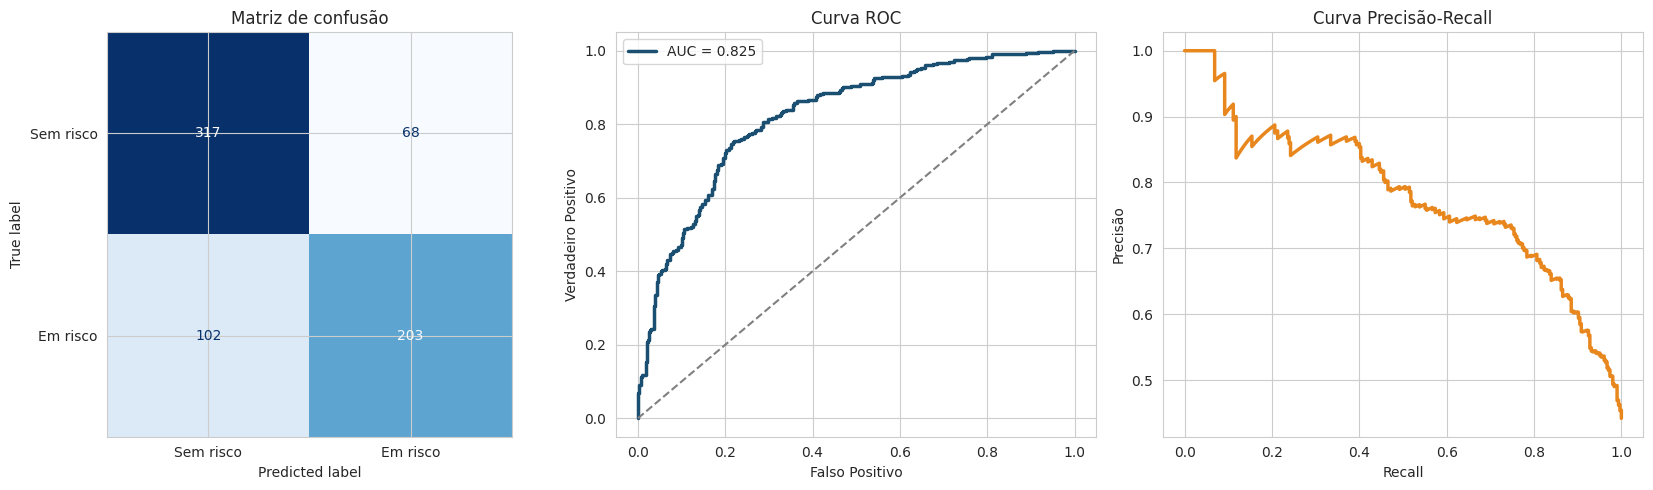

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(17,5))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Sem risco","Em risco"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusão")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color=COR_AZUL, linewidth=2.5, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0,1],[0,1], linestyle="--", color="gray")
axes[1].set_xlabel("Falso Positivo"); axes[1].set_ylabel("Verdadeiro Positivo")
axes[1].set_title("Curva ROC"); axes[1].legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color=COR_LARANJA, linewidth=2.5)
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precisão")
axes[2].set_title("Curva Precisão-Recall")

plt.tight_layout()
plt.savefig("../presentation/fig_modelo_avaliacao.png", dpi=150, bbox_inches="tight")
plt.show()


**Leitura das métricas:**
- **AUC-ROC** mede a capacidade geral do modelo de separar alunos em risco dos que não estão,
  independente de limiar de decisão — quanto mais perto de 1, melhor.
- A **matriz de confusão** mostra o equilíbrio entre falsos positivos (alertas desnecessários)
  e falsos negativos (casos de risco não detectados) — este segundo tipo de erro é o mais
  custoso no contexto social do programa, por isso vale considerar limiares que priorizem recall.


## 4.1 Importância das variáveis

Quais indicadores mais pesam na previsão de risco?


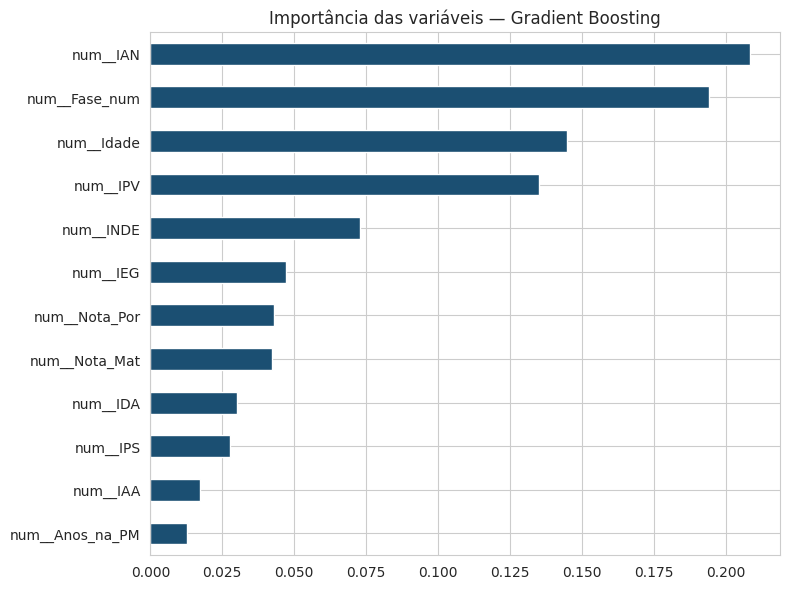

In [9]:

try:
    clf = pipe_final.named_steps["clf"]
    feature_names = pipe_final.named_steps["prep"].get_feature_names_out()
    if hasattr(clf, "feature_importances_"):
        importancias = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    else:
        importancias = pd.Series(np.abs(clf.coef_[0]), index=feature_names).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8,6))
    importancias.head(12).sort_values().plot(kind="barh", color=COR_AZUL, ax=ax)
    ax.set_title(f"Importância das variáveis — {melhor_nome}")
    plt.tight_layout()
    plt.savefig("../presentation/fig_modelo_importancia.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("Não foi possível extrair importâncias diretamente:", e)


## 5. Exportação do modelo treinado

Salvamos o pipeline completo (pré-processamento + modelo) com `joblib`, para ser consumido
diretamente pela aplicação Streamlit (`app/app.py`), sem necessidade de re-treinar.


In [10]:

import os
os.makedirs("../app/model", exist_ok=True)

joblib.dump(pipe_final, "../app/model/modelo_risco_defasagem.joblib")
joblib.dump(FEATURES_NUM, "../app/model/features_num.joblib")
joblib.dump(FEATURES_CAT, "../app/model/features_cat.joblib")

print("Modelo e metadados salvos em ../app/model/")
print("Modelo utilizado:", melhor_nome)


Modelo e metadados salvos em ../app/model/
Modelo utilizado: Gradient Boosting


## Conclusão

O pipeline treinado (`modelo_risco_defasagem.joblib`) recebe os indicadores do ano corrente de
um aluno e retorna a **probabilidade de risco de defasagem no ano seguinte**, permitindo à
equipe da Passos Mágicos priorizar intervenções pedagógicas e psicossociais de forma proativa,
antes que a defasagem efetivamente ocorra.
